In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve,recall_score,accuracy_score,precision_score

In [ ]:
df=pd.read_csv('/content/job_placement.csv')

In [ ]:
df.head()

,id,name,gender,age,degree,stream,college_name,placement_status,salary,gpa,years_of_experience
0,1,John Doe,Male,25,Bachelor's,Computer Science,Harvard University,Placed,60000,3.7,2.0
1,2,Jane Smith,Female,24,Bachelor's,Electrical Engineering,Massachusetts Institute of Technology,Placed,65000,3.6,1.0
2,3,Michael Johnson,Male,26,Bachelor's,Mechanical Engineering,Stanford University,Placed,58000,3.8,3.0
3,4,Emily Davis,Female,23,Bachelor's,Information Technology,Yale University,Not Placed,0,3.5,2.0
4,5,David Brown,Male,24,Bachelor's,Computer Science,Princeton University,Placed,62000,3.9,2.0


In [ ]:
df.shape

(700, 11)

In [ ]:
df.describe()

,id,age,salary,gpa,years_of_experience
count,700.00000,700.000000,700.000000,700.000000,699.000000
mean,350.50000,24.411429,52474.285714,3.750429,2.177396
std,202.21688,1.164268,25160.331005,0.121212,0.779393
min,1.00000,23.000000,0.000000,3.400000,1.000000
25%,175.75000,23.000000,61000.000000,3.700000,2.000000
50%,350.50000,24.000000,64000.000000,3.800000,2.000000
75%,525.25000,26.000000,66000.000000,3.900000,3.000000
max,700.00000,26.000000,68000.000000,3.900000,3.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   700 non-null    int64  
 1   name                 700 non-null    object 
 2   gender               700 non-null    object 
 3   age                  700 non-null    int64  
 4   degree               700 non-null    object 
 5   stream               700 non-null    object 
 6   college_name         700 non-null    object 
 7   placement_status     700 non-null    object 
 8   salary               700 non-null    int64  
 9   gpa                  700 non-null    float64
 10  years_of_experience  699 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 60.3+ KB


In [ ]:
print("no of duplicate records:",df.duplicated().sum())

no of duplicate records: 0


In [ ]:
df.isnull().sum()

,0
id,0
name,0
gender,0
age,0
degree,0
stream,0
college_name,0
placement_status,0
salary,0
gpa,0


In [ ]:
#remove null
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
gender,0
age,0
degree,0
stream,0
college_name,0
placement_status,0
salary,0
gpa,0


In [ ]:
#feature summary
numerical_features=df.select_dtypes(include=['int64','float64']).columns
categorical_features=df.select_dtypes(include=['object']).columns
print("Feature Summary")
print("numerical features")
for col in numerical_features:
  print("-",col)
print("categorical Features")
for col in categorical_features:
  print("-",col)


Feature Summary
numerical features
- id
- age
- salary
- gpa
- years_of_experience
categorical Features
- name
- gender
- degree
- stream
- college_name
- placement_status


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()
df['gender']=le.fit_transform(df['gender'])
df['degree']=le.fit_transform(df['degree'])

In [ ]:
# Target Column Encoding
# df['loan_status'] = df['loan_status'].str.strip().map({
# 'Approved': 1,
# 'Rejected': 0
# })

In [ ]:
#separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [ ]:
#model building
model=DecisionTreeClassifier()

# Drop non-numeric and high-cardinality categorical columns from x_train
# These columns include 'name', 'stream', 'college_name', 'placement_status'
# which were not label encoded or dropped in previous steps.
# The error 'could not convert string to float: 'Amelia Smith'' specifically points to 'name'.
problematic_columns = ['id', 'name', 'stream', 'college_name', 'placement_status']
# Ensure columns exist in x_train before dropping
columns_to_drop = [col for col in problematic_columns if col in x_train.columns]

if columns_to_drop:
    x_train_processed = x_train.drop(columns=columns_to_drop, errors='ignore')
else:
    x_train_processed = x_train.copy() # Make a copy to avoid SettingWithCopyWarning if no columns dropped

model.fit(x_train_processed,y_train)

DecisionTreeClassifier()

In [ ]:
#predictions on test data

# Drop the same problematic columns from x_test that were dropped from x_train
problematic_columns = ['id', 'name', 'stream', 'college_name', 'placement_status']
columns_to_drop_from_test = [col for col in problematic_columns if col in x_test.columns]

if columns_to_drop_from_test:
    x_test_processed = x_test.drop(columns=columns_to_drop_from_test, errors='ignore')
else:
    x_test_processed = x_test.copy() # Make a copy to avoid SettingWithCopyWarning if no columns dropped

y_pred=model.predict(x_test_processed)

In [ ]:
#evaluation metrics
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9857142857142858


In [ ]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[31  1  0]
 [ 1 50  0]
 [ 0  0 57]]
              precision    recall  f1-score   support

         1.0       0.97      0.97      0.97        32
         2.0       0.98      0.98      0.98        51
         3.0       1.00      1.00      1.00        57

    accuracy                           0.99       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.99      0.99      0.99       140

0.9857142857142858


In [ ]:
# Training Accuracy
train_accuracy = model.score(x_train_processed, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test_processed, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 99.46%
Testing Accuracy: 98.57%


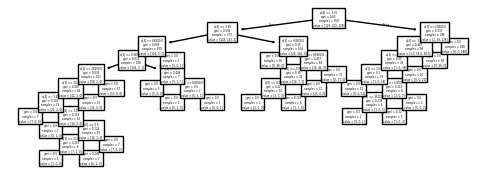

In [ ]:
#display decision tree
from sklearn import tree
plt.figure(figsize=(10,2))
tree.plot_tree(model)
plt.show()

In [ ]:
#auc_roc_score
from sklearn.metrics import roc_auc_score
# Use predict_proba to get class probabilities for roc_auc_score with multi_class='ovr'
y_pred_proba = model.predict_proba(x_test_processed)
roc_auc_score(y_test, y_pred_proba, multi_class='ovr')

np.float64(0.9879379355258542)

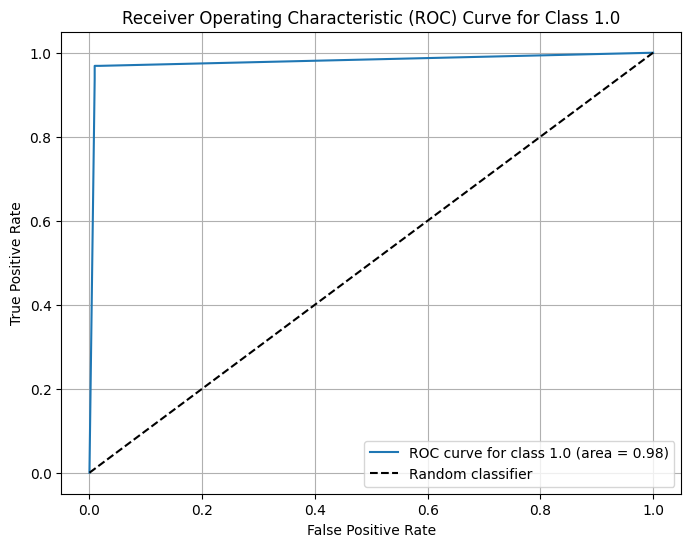

In [ ]:
#roc_curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Define the target class for which to plot the ROC curve
target_class = 1.0 # Example: plot for class 1.0

plt.figure(figsize=(8, 6))

# Binarize y_test for the target class (one-vs-rest)
y_test_binary = (y_test == target_class).astype(int)

# Get the index of the target class in model.classes_
class_index = list(model.classes_).index(target_class)

# Get predicted probabilities for the target class
y_score_class = y_pred_proba[:, class_index]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score_class)

# Plot the ROC curve
plt.plot(fpr, tpr, label=f'ROC curve for class {target_class} (area = {roc_auc_score(y_test_binary, y_score_class):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier') # Dashed diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Class {target_class}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()